# Week 10 Homework: ARIA v7.0 — The All-Weather Auditor

**Student:** Huang YongZhi
**Course:** NTU 遙測與空間資訊之分析與應用
**Instructor:** Prof. Su Wen-Ray (蘇文瑞教授)
**Case Study:** 花蓮 / 馬太鞍流域 × 鳳凰颱風 (Typhoon Fung-wong, 2025-11)
**Notebook:** `Week10_ARIA_v70_HuangYongZhi.ipynb`

---

## ARIA v7.0 — All-Weather Auditor

延續 W8–W9 的光學變遷偵測，本週將 SAR 資料納入 ARIA 系統，建立**全天候災情判讀引擎**。

| Task | 占比 | 內容 |
|------|------|------|
| Task 1 | 25% | SAR 全天候淹水偵測（speckle filter + threshold + 形態學清理）|
| Task 2 | 30% | 4-class Sensor Fusion（SAR ∩ NDWI + Cloud mask）|
| Task 3 | 20% | DEM 地形審計（slope > 25° 過濾）|
| Task 4 | 25% | AI 戰略簡報 (Gemini) + W9 vs W10 比較 |

### 鳳凰颱風事件時序

- **2025-10-16**：Sentinel-2 雲量 2.5% — 颱風前清晰基準 ✅
- **2025-11-02**：Sentinel-2 雲量 100% — 颱風峰值，光學完全失明 ☁☁☁
- **2025-11-05**：Sentinel-1 ascending — 颱風後 SAR 穿雲影像 ✅
- **2025-11-15**：Sentinel-2 雲量 46% — 部分散去，可做融合 ✅

> **核心命題**：颱風期間光學失明（11/02 雲量 100%），ARIA v7.0 必須靠 SAR 提供地表事實。

## Captain's Log #1 — Setup & Data Acquisition

**目標**：透過 STAC 串流取得 Sentinel-1 RTC（pre/post 鳳凰）與 Sentinel-2 L2A（baseline + post + 雲牆 demo），全程不下載原始檔。

**設計選擇**：
- **bbox 與 W9 一致** `[121.28, 23.56, 121.52, 23.76]` — 馬太鞍流域 + 花蓮平原南段
- **軌道一致**（pre/post 都用 ascending）— 避免升降軌幾何偽影
- **閾值起始值**：SAR -18 dB（ARIA 文獻預設）+ NDWI 0.0（濁水流域必須降低）
- **參數從 `.env` 讀取**，notebook 內不寫死數值

**預期**：6 個 STAC item（2× S1 + 4× S2），全部串流，總體 < 1 GB 記憶體。

In [1]:
# [S1] Environment Setup + .env Loading
# ──────────────────────────────────────────────────────────────────
import os, time, warnings
warnings.filterwarnings('ignore')

# GDAL HTTP retry for reliable COG streaming
os.environ.setdefault('GDAL_HTTP_MAX_RETRY', '5')
os.environ.setdefault('GDAL_HTTP_RETRY_DELAY', '2')
os.environ.setdefault('GDAL_HTTP_TIMEOUT', '60')
os.environ.setdefault('GDAL_HTTP_MULTIRANGE', 'YES')
os.environ.setdefault('VSI_CACHE', 'TRUE')
os.environ.setdefault('VSI_CACHE_SIZE', '1000000000')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.ndimage import median_filter, binary_opening, label, zoom as scipy_zoom
import xarray as xr
import rioxarray as rxr
import rasterio
import pystac_client
import planetary_computer as pc
import stackstac
from dotenv import load_dotenv

plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'PingFang TC', 'Heiti TC', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['axes.grid'] = False

# ── Load .env ───────────────────────────────────────────────────
load_dotenv()

def envf(key, default):
    return float(os.getenv(key, default))

def envi(key, default):
    return int(os.getenv(key, default))

BBOX = [envf('BBOX_WEST', 121.28),
        envf('BBOX_SOUTH', 23.56),
        envf('BBOX_EAST', 121.52),
        envf('BBOX_NORTH', 23.76)]
TARGET_EPSG = envi('TARGET_EPSG', 32651)
DEM_PATH = os.getenv('DEM_PATH', '../../data/Hualien_dem_merge.tif')
DEM_EPSG = envi('DEM_EPSG', 3826)

S1_COLLECTION = os.getenv('S1_COLLECTION', 'sentinel-1-rtc')
S1_PRE_DATE   = os.getenv('S1_PRE_DATE',   '2025-10-30')
S1_POST_DATE  = os.getenv('S1_POST_DATE',  '2025-11-05')
S1_ORBIT_STATE = os.getenv('S1_ORBIT_STATE', 'ascending')

S2_COLLECTION = os.getenv('S2_COLLECTION', 'sentinel-2-l2a')
S2_PRE_DATE   = os.getenv('S2_PRE_DATE',   '2025-10-16')
S2_POST_DATE  = os.getenv('S2_POST_DATE',  '2025-11-15')
S2_PEAK_CLOUD_DATE = os.getenv('S2_PEAK_CLOUD_DATE', '2025-11-02')

SAR_THRESHOLD  = envf('SAR_THRESHOLD',  -18)
NDWI_THRESHOLD = envf('NDWI_THRESHOLD',  0.0)
SLOPE_THRESHOLD = envf('SLOPE_THRESHOLD', 25)
MIN_WATER_PIXELS = envi('MIN_WATER_PIXELS', 50)

OUTPUT_DIR = 'output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── STAC Catalog ────────────────────────────────────────────────
catalog = pystac_client.Client.open(
    'https://planetarycomputer.microsoft.com/api/stac/v1',
    modifier=pc.sign_inplace,
)

def safe_compute(lazy_arr, tries=4):
    from rasterio.errors import RasterioIOError
    last_err = None
    for attempt in range(tries):
        try:
            return lazy_arr.compute()
        except (RasterioIOError, RuntimeError) as e:
            last_err = e
            time.sleep(2 ** attempt)
    raise RuntimeError(f'COG read failed after {tries} attempts: {last_err}')

print('✅ Environment ready')
print(f'   BBOX (Hualien/Matai\'an): {BBOX}')
print(f'   SAR threshold: {SAR_THRESHOLD} dB | NDWI: {NDWI_THRESHOLD} | Slope: {SLOPE_THRESHOLD}°')
print(f'   Pre SAR: {S1_PRE_DATE} | Post SAR: {S1_POST_DATE} ({S1_ORBIT_STATE})')
print(f'   Pre S2:  {S2_PRE_DATE}  | Post S2: {S2_POST_DATE}  | Peak cloud: {S2_PEAK_CLOUD_DATE}')

✅ Environment ready
   BBOX (Hualien/Matai'an): [121.28, 23.56, 121.52, 23.76]
   SAR threshold: -18.0 dB | NDWI: 0.0 | Slope: 25.0°
   Pre SAR: 2025-10-30 | Post SAR: 2025-11-05 (ascending)
   Pre S2:  2025-10-16  | Post S2: 2025-11-15  | Peak cloud: 2025-11-02


In [2]:
# [S2] STAC Search — Sentinel-1 + Sentinel-2 scenes for Fung-wong period
# ──────────────────────────────────────────────────────────────────

def search_one_day(collection, target_date, bbox=BBOX, orbit_state=None, max_items=10, tries=4):
    """Search a single date +/- 2 days with retry; pick orbit-matching scene closest to target."""
    from datetime import datetime, timedelta
    d = datetime.strptime(target_date, '%Y-%m-%d')
    rng = f'{(d - timedelta(days=2)).strftime("%Y-%m-%d")}/{(d + timedelta(days=2)).strftime("%Y-%m-%d")}'
    last_err = None
    for attempt in range(tries):
        try:
            items = list(catalog.search(collections=[collection], bbox=bbox,
                                        datetime=rng, max_items=max_items).items())
            if orbit_state:
                items = [i for i in items
                         if i.properties.get('sat:orbit_state', '').lower() == orbit_state.lower()]
            items.sort(key=lambda i: abs(
                (datetime.strptime(i.properties['datetime'][:10], '%Y-%m-%d') - d).days))
            return items[0] if items else None
        except Exception as e:
            last_err = e
            time.sleep(3 * (2 ** attempt))
    raise RuntimeError(f'STAC search failed after {tries} attempts: {last_err}')

print('=== Sentinel-1 SAR (Pre/Post Fung-wong) ===')
s1_pre  = search_one_day(S1_COLLECTION, S1_PRE_DATE,  orbit_state=S1_ORBIT_STATE)
s1_post = search_one_day(S1_COLLECTION, S1_POST_DATE, orbit_state=S1_ORBIT_STATE)
for label_, it in [('PRE', s1_pre), ('POST', s1_post)]:
    print(f'  {label_:4s}: {it.properties["datetime"][:16]} | '
          f'orbit={it.properties.get("sat:orbit_state","?")} | '
          f'id={it.id[:50]}')

print()
print('=== Sentinel-2 L2A (3 scenes: pre baseline / peak cloud / post) ===')
s2_pre  = search_one_day(S2_COLLECTION, S2_PRE_DATE,  max_items=5)
s2_peak = search_one_day(S2_COLLECTION, S2_PEAK_CLOUD_DATE, max_items=5)
s2_post = search_one_day(S2_COLLECTION, S2_POST_DATE, max_items=5)
for label_, it in [('PRE  (baseline)', s2_pre),
                    ('PEAK (cloud demo)', s2_peak),
                    ('POST (fusion)', s2_post)]:
    cc = it.properties.get('eo:cloud_cover', -1)
    print(f'  {label_}: {it.properties["datetime"][:16]} | cloud={cc:5.1f}%')

assert s1_pre and s1_post and s2_pre and s2_peak and s2_post, 'Missing scenes!'

=== Sentinel-1 SAR (Pre/Post Fung-wong) ===


  PRE : 2025-10-30T10:00 | orbit=ascending | id=S1C_IW_GRDH_1SDV_20251030T100018_20251030T100043_0
  POST: 2025-11-05T10:01 | orbit=ascending | id=S1A_IW_GRDH_1SDV_20251105T100123_20251105T100148_0

=== Sentinel-2 L2A (3 scenes: pre baseline / peak cloud / post) ===


  PRE  (baseline): 2025-10-16T02:25 | cloud=  2.5%
  PEAK (cloud demo): 2025-11-02T02:31 | cloud=100.0%
  POST (fusion): 2025-11-15T02:28 | cloud= 46.2%


## Captain's Log #2 — Task 1: SAR All-Weather Flood Detection

**為什麼用 SAR**：鳳凰颱風 11/02 Sentinel-2 雲量 100%，光學完全失明。SAR 不受雲層影響，是颱風中唯一可用訊號。

**處理流程**：
```
Sentinel-1 RTC (linear σ⁰) → 10·log₁₀ → dB
  → Median filter 5×5  ← 必須先濾波，否則 speckle 產生大量假水體
  → Threshold: VV < -18 dB  ← ARIA 文獻預設值
  → Morphological opening (3×3, 1 iter)  ← 去零碎雜訊
  → Connected component (>= 50 px = 0.5 ha)  ← 去小於 0.5 ha 的碎片
  → Final water mask
```

**門檻選擇理由**：本案例為花蓮平原一般淹水（非堰塞湖泥沙水），用 ARIA 文獻預設 -18 dB；如果結果不合理（過估或低估）會回頭調整並記錄。

In [3]:
# [S3] Stream Sentinel-1 RTC + Linear→dB Conversion
# ──────────────────────────────────────────────────────────────────

def stream_sar(item, bands=['vv'], bbox=BBOX, epsg=TARGET_EPSG):
    """Stream Sentinel-1 RTC as lazy xarray (linear backscatter)."""
    signed = pc.sign(item)
    cube = stackstac.stack(
        [signed], assets=bands, epsg=epsg, resolution=10,
        bounds_latlon=bbox, chunksize=2048,
    ).squeeze('time')
    return cube

print('Loading Pre SAR (VV)...')
vv_pre_linear = safe_compute(stream_sar(s1_pre, ['vv']))
vv_pre_db = 10 * np.log10(vv_pre_linear.values.squeeze().astype(np.float32))
vv_pre_db = np.where(np.isfinite(vv_pre_db), vv_pre_db, np.nan)

print('Loading Post SAR (VV)...')
vv_post_linear = safe_compute(stream_sar(s1_post, ['vv']))
vv_post_db = 10 * np.log10(vv_post_linear.values.squeeze().astype(np.float32))
vv_post_db = np.where(np.isfinite(vv_post_db), vv_post_db, np.nan)

H, W = vv_post_db.shape
PIXEL_AREA_KM2 = (10 * 10) / 1_000_000   # 10m × 10m → km²

print(f'\n  Pre  shape: {vv_pre_db.shape},  range: {np.nanmin(vv_pre_db):.1f} ~ {np.nanmax(vv_pre_db):.1f} dB')
print(f'  Post shape: {vv_post_db.shape}, range: {np.nanmin(vv_post_db):.1f} ~ {np.nanmax(vv_post_db):.1f} dB')
print(f'  Total pixels: {H*W:,} | Area covered: {H*W*PIXEL_AREA_KM2:.1f} km²')

Loading Pre SAR (VV)...


Loading Post SAR (VV)...



  Pre  shape: (2243, 2474),  range: -30.6 ~ 27.1 dB
  Post shape: (2243, 2474), range: -28.0 ~ 27.2 dB
  Total pixels: 5,549,182 | Area covered: 554.9 km²


In [4]:
# [S4] Task 1: Speckle Filter + Threshold + Morphological Cleanup
# ──────────────────────────────────────────────────────────────────

# Step 1: Median filter to suppress speckle
sar_filtered = median_filter(vv_post_db, size=5)

# Step 2: Threshold (ARIA default -18 dB)
sar_water_raw = (sar_filtered < SAR_THRESHOLD).astype(np.uint8)
raw_count = int(np.sum(sar_water_raw))

# Step 3a: Morphological opening (erode → dilate)
sar_water_opened = binary_opening(sar_water_raw,
                                   structure=np.ones((3, 3)),
                                   iterations=1).astype(np.uint8)
opened_count = int(np.sum(sar_water_opened))

# Step 3b: Connected component filtering
labeled, n_features = label(sar_water_opened)
sar_water = np.zeros_like(sar_water_opened)
kept, removed = 0, 0
for region_id in range(1, n_features + 1):
    region_size = int(np.sum(labeled == region_id))
    if region_size >= MIN_WATER_PIXELS:
        sar_water[labeled == region_id] = 1
        kept += 1
    else:
        removed += 1

water_n = int(np.sum(sar_water))
flood_km2 = water_n * PIXEL_AREA_KM2
flood_ha = flood_km2 * 100

print(f'Step 1: Median filter (5×5) — speckle suppressed')
print(f'Step 2: Threshold VV < {SAR_THRESHOLD} dB → {raw_count:,} px '
      f'({raw_count*PIXEL_AREA_KM2:.2f} km²)')
print(f'Step 3a: Morphological opening → {opened_count:,} px '
      f'(removed {raw_count-opened_count:,} fragments)')
print(f'Step 3b: Connected components → {n_features} regions found')
print(f'         Kept {kept} regions ≥ {MIN_WATER_PIXELS} px '
      f'(= {MIN_WATER_PIXELS*PIXEL_AREA_KM2*100:.1f} ha)')
print(f'         Removed {removed} small fragments')
print()
print(f'✅ Final SAR water mask: {water_n:,} px = {flood_km2:.2f} km² ({flood_ha:.1f} ha)')
print(f'   Mean dB in flood zone: {np.nanmean(sar_filtered[sar_water==1]):.1f} dB')

# Save Task 1 statistics
import csv
with open(f'{OUTPUT_DIR}/HW10_T1_stats.csv', 'w', newline='', encoding='utf-8') as f:
    w = csv.writer(f)
    w.writerow(['stage', 'pixels', 'km2', 'ha'])
    w.writerow(['raw_threshold', raw_count, raw_count*PIXEL_AREA_KM2, raw_count*PIXEL_AREA_KM2*100])
    w.writerow(['after_opening', opened_count, opened_count*PIXEL_AREA_KM2, opened_count*PIXEL_AREA_KM2*100])
    w.writerow(['final_water', water_n, flood_km2, flood_ha])
print(f'\n  → Saved HW10_T1_stats.csv')

Step 1: Median filter (5×5) — speckle suppressed
Step 2: Threshold VV < -18.0 dB → 27,565 px (2.76 km²)
Step 3a: Morphological opening → 23,867 px (removed 3,698 fragments)
Step 3b: Connected components → 368 regions found
         Kept 123 regions ≥ 50 px (= 0.5 ha)
         Removed 245 small fragments

✅ Final SAR water mask: 18,529 px = 1.85 km² (185.3 ha)
   Mean dB in flood zone: -19.4 dB

  → Saved HW10_T1_stats.csv


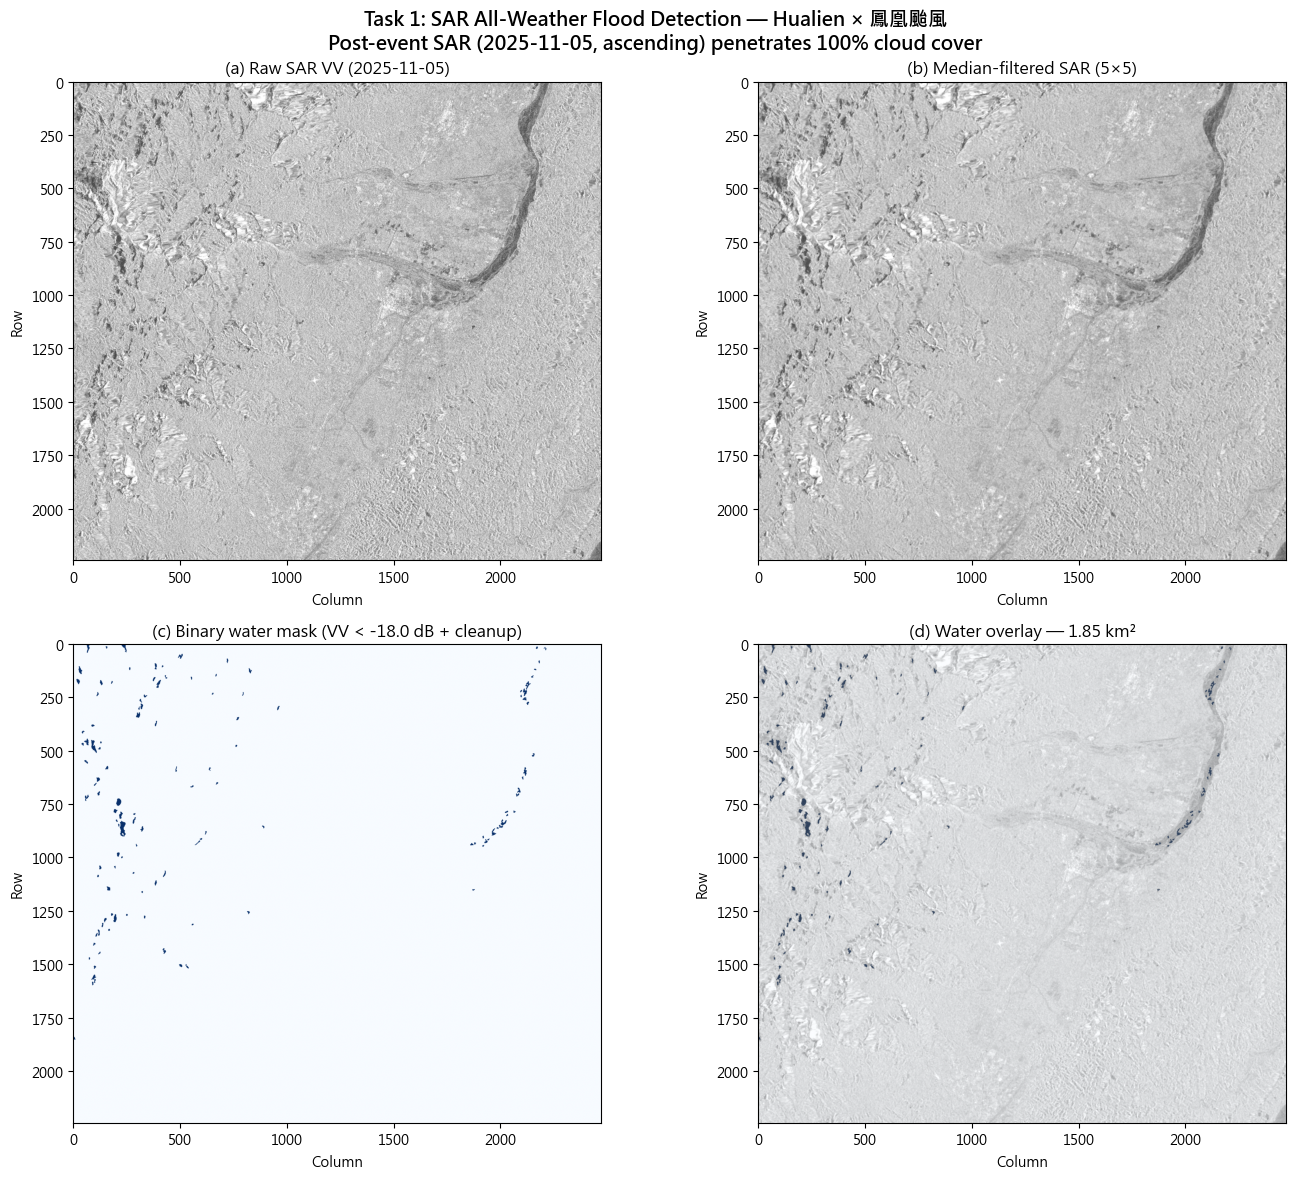

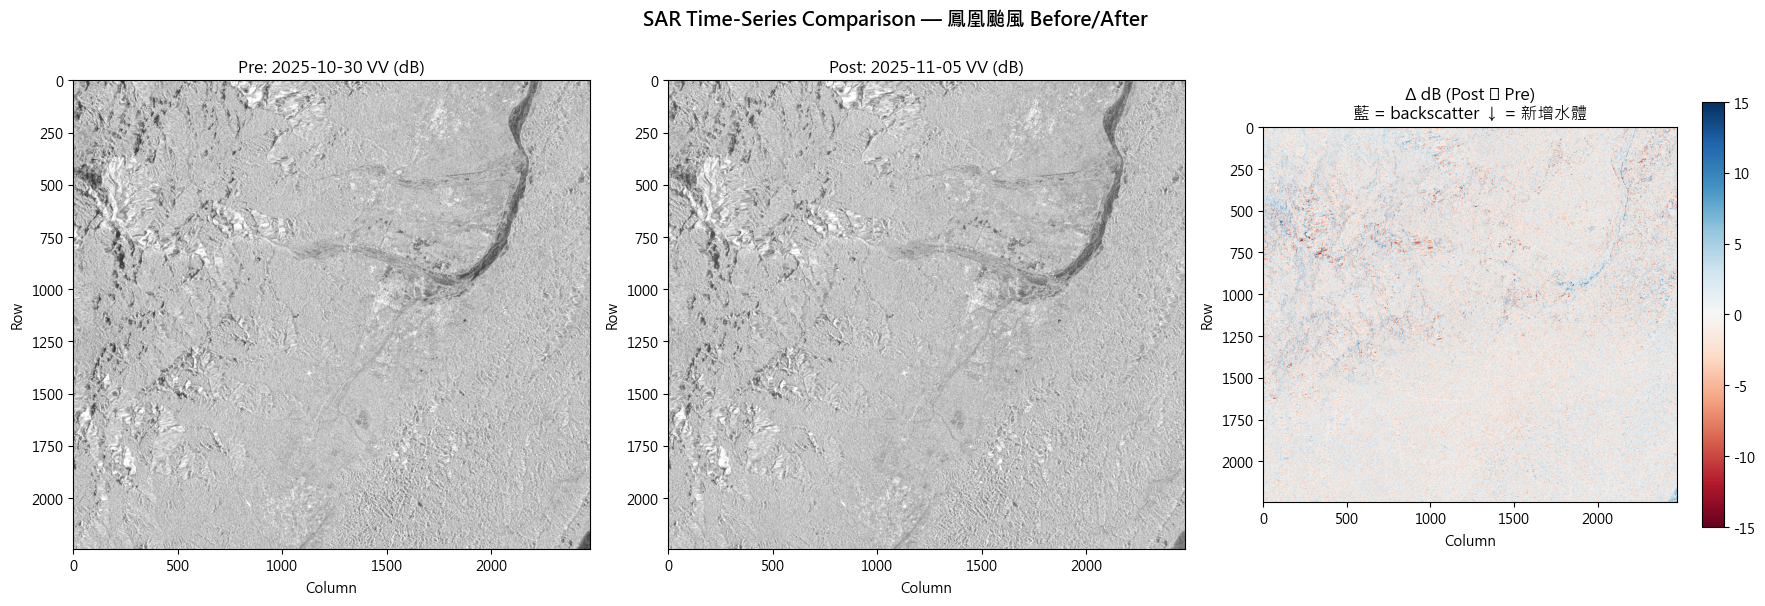


📌 SAR detected 1.85 km² of flooding that optical sensors could not see due to 100% cloud cover on 2025-11-02.


In [5]:
# [S5] Task 1 Visualization — 2x2 panel
# (a) Raw SAR  (b) Filtered SAR  (c) Binary mask  (d) Overlay
# ──────────────────────────────────────────────────────────────────

post_date = s1_post.properties['datetime'][:10]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

axes[0,0].imshow(vv_post_db, cmap='gray', vmin=-30, vmax=0)
axes[0,0].set_title(f'(a) Raw SAR VV ({post_date})')

axes[0,1].imshow(sar_filtered, cmap='gray', vmin=-30, vmax=0)
axes[0,1].set_title('(b) Median-filtered SAR (5×5)')

axes[1,0].imshow(sar_water, cmap='Blues', vmin=0, vmax=1)
axes[1,0].set_title(f'(c) Binary water mask (VV < {SAR_THRESHOLD} dB + cleanup)')

axes[1,1].imshow(sar_filtered, cmap='gray', vmin=-30, vmax=0)
axes[1,1].imshow(sar_water, cmap='Blues', alpha=0.45)
axes[1,1].set_title(f'(d) Water overlay — {flood_km2:.2f} km²')

for ax in axes.flat:
    ax.set_xlabel('Column'); ax.set_ylabel('Row')

plt.suptitle(f'Task 1: SAR All-Weather Flood Detection — Hualien × 鳳凰颱風\n'
             f'Post-event SAR ({post_date}, {S1_ORBIT_STATE}) penetrates 100% cloud cover',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/HW10_T1_sar_panel.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Side-by-side pre/post for change detection ─────────────────
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 6))
axes2[0].imshow(vv_pre_db, cmap='gray', vmin=-30, vmax=0)
axes2[0].set_title(f'Pre: {S1_PRE_DATE} VV (dB)')
axes2[1].imshow(vv_post_db, cmap='gray', vmin=-30, vmax=0)
axes2[1].set_title(f'Post: {post_date} VV (dB)')
diff_db = vv_post_db - vv_pre_db
im = axes2[2].imshow(diff_db, cmap='RdBu', vmin=-15, vmax=15)
axes2[2].set_title('Δ dB (Post − Pre)\n藍 = backscatter ↓ = 新增水體')
plt.colorbar(im, ax=axes2[2], shrink=0.8)
for ax in axes2: ax.set_xlabel('Column'); ax.set_ylabel('Row')
plt.suptitle('SAR Time-Series Comparison — 鳳凰颱風 Before/After', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/HW10_T1_change_detection.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📌 SAR detected {flood_km2:.2f} km² of flooding that optical sensors '
      f'could not see due to 100% cloud cover on {S2_PEAK_CLOUD_DATE}.')

## Captain's Log #3 — Task 2: Multi-Source Confidence Fusion

**為什麼融合**：SAR 單獨判讀會把 radar shadow、平靜河道、稻田都誤認為水。光學 NDWI 可以幫忙確認 — 但只在雲開的地方才有效。

**4-class 分級**：

| Class | 條件 | 解讀 |
|-------|------|------|
| **3 High Confidence** | NDWI ✓ ∩ SAR ✓ | 雙感測器確認，可靠 |
| **2 SAR Only (Cloudy)** | SAR ✓ ∩ Cloud ✓ | 雲下 SAR 補充，可信度中 |
| **1 Optical Only** | NDWI ✓ ∩ SAR ✗ ∩ ¬Cloud | 光學單獨偵測，需人工複核 |
| **0 No Detection** | 其他 | 未偵測到水 |

**NDWI 閾值 0.0**：W9 已驗證（清水用 0.3，馬太鞍泥沙水用 0.0）。鳳凰颱風帶來大量懸浮泥沙，沿用 0.0。

**雲遮罩**：用 SCL（Scene Classification Layer）的 clear classes [2, 4, 5, 6, 7, 11] = dark / vegetation / bare / water / snow / shadow。

In [6]:
# [S6] Stream Sentinel-2 — NDWI + Cloud Mask (W9 pipeline)
# ──────────────────────────────────────────────────────────────────

SCL_CLEAR_CLASSES = [2, 4, 5, 6, 7, 11]   # dark, vegetation, bare, water, snow, shadow

def stream_s2(item, bands, bbox=BBOX, epsg=TARGET_EPSG):
    signed = pc.sign(item)
    return stackstac.stack(
        [signed], assets=bands, epsg=epsg, resolution=10,
        bounds_latlon=bbox, chunksize=2048,
    ).squeeze('time') / 10000.0

def stream_scl(item, bbox=BBOX, epsg=TARGET_EPSG):
    signed = pc.sign(item)
    return safe_compute(stackstac.stack(
        [signed], assets=['SCL'], epsg=epsg, resolution=10,
        bounds_latlon=bbox, chunksize=2048,
    ).squeeze('time').squeeze('band'))

print(f'Loading Sentinel-2 POST ({S2_POST_DATE}) — NDWI + SCL...')
cube_post = stream_s2(s2_post, ['B03', 'B08'])
green_post = safe_compute(cube_post.sel(band='B03')).values
nir_post = safe_compute(cube_post.sel(band='B08')).values
ndwi_post = (green_post - nir_post) / (green_post + nir_post + 1e-9)
ndwi_water_mask = (ndwi_post > NDWI_THRESHOLD).astype(np.uint8)

scl_post = stream_scl(s2_post)
scl_arr = scl_post.values
cloud_mask = (~np.isin(scl_arr, SCL_CLEAR_CLASSES)).astype(np.uint8)

# Align to SAR grid (H, W)
if ndwi_water_mask.shape != (H, W):
    ndwi_water_mask = scipy_zoom(ndwi_water_mask, (H/ndwi_water_mask.shape[0],
                                                    W/ndwi_water_mask.shape[1]), order=0)
if cloud_mask.shape != (H, W):
    cloud_mask = scipy_zoom(cloud_mask, (H/cloud_mask.shape[0],
                                          W/cloud_mask.shape[1]), order=0)

cloud_pct = np.mean(cloud_mask) * 100
print(f'  NDWI water (>{NDWI_THRESHOLD}): {int(np.sum(ndwi_water_mask)):,} px '
      f'({np.sum(ndwi_water_mask)*PIXEL_AREA_KM2:.2f} km²)')
print(f'  Cloud-masked: {cloud_pct:.1f}% of scene')

# ── Also load peak-cloud day to demonstrate full cloud blindness ──
print(f'\nLoading Sentinel-2 PEAK CLOUD ({S2_PEAK_CLOUD_DATE}) — SCL only for demo...')
scl_peak = stream_scl(s2_peak)
cloud_peak = (~np.isin(scl_peak.values, SCL_CLEAR_CLASSES)).astype(np.uint8)
if cloud_peak.shape != (H, W):
    cloud_peak = scipy_zoom(cloud_peak, (H/cloud_peak.shape[0], W/cloud_peak.shape[1]), order=0)
cloud_peak_pct = np.mean(cloud_peak) * 100
print(f'  Peak cloud day: {cloud_peak_pct:.1f}% obscured — 光學完全失明')

Loading Sentinel-2 POST (2025-11-15) — NDWI + SCL...


  NDWI water (>0.0): 627,926 px (62.79 km²)
  Cloud-masked: 88.6% of scene

Loading Sentinel-2 PEAK CLOUD (2025-11-02) — SCL only for demo...


  Peak cloud day: 100.0% obscured — 光學完全失明


=== Task 2: 4-Class Sensor Fusion Area Statistics ===
Class                         Pixels      km²       ha
-------------------------------------------------------
No Detection               5,501,761   550.18  55017.6
Optical Only                  31,457     3.15    314.6
SAR Only (Cloudy)             11,405     1.14    114.1
High Confidence                4,559     0.46     45.6

  → Saved HW10_T2_fusion_stats.csv


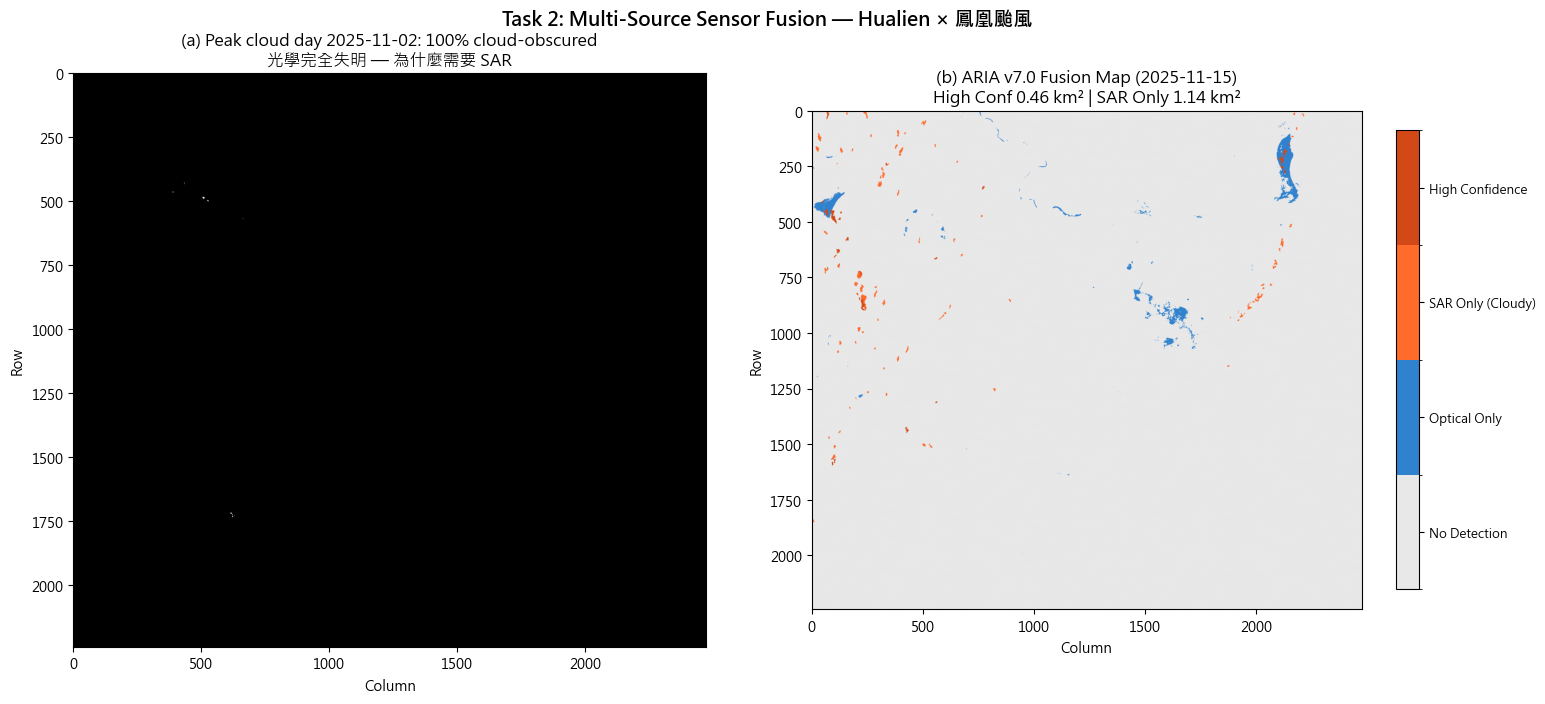


📌 High confidence zones cover 0.46 km² (dual-sensor confirmed).
   SAR-only zones add 1.14 km² of flood detection in cloudy areas — these are zones where optical alone would have missed.


In [7]:
# [S7] Task 2: 4-class Sensor Fusion + Area Statistics
# ──────────────────────────────────────────────────────────────────

# Verify aligned grid
assert sar_water.shape == ndwi_water_mask.shape == cloud_mask.shape == (H, W), \
    'Grid alignment failed!'

fusion = np.zeros((H, W), dtype=np.uint8)
fusion[(ndwi_water_mask == 1) & (sar_water == 1)] = 3                         # High Conf
fusion[(cloud_mask == 1) & (sar_water == 1) & (fusion != 3)] = 2              # SAR Only
fusion[(ndwi_water_mask == 1) & (sar_water == 0) & (cloud_mask == 0)] = 1     # Optical Only

class_labels = {0: 'No Detection', 1: 'Optical Only', 2: 'SAR Only (Cloudy)', 3: 'High Confidence'}

# Area statistics
print('=== Task 2: 4-Class Sensor Fusion Area Statistics ===')
print(f'{"Class":<25s} {"Pixels":>10s} {"km²":>8s} {"ha":>8s}')
print('-' * 55)
fusion_stats = []
for v, lbl in class_labels.items():
    n = int(np.sum(fusion == v))
    km2 = n * PIXEL_AREA_KM2
    ha = km2 * 100
    fusion_stats.append({'class': v, 'label': lbl, 'pixels': n, 'km2': km2, 'ha': ha})
    print(f'{lbl:<25s} {n:>10,} {km2:>8.2f} {ha:>8.1f}')

# Save CSV
df_fusion = pd.DataFrame(fusion_stats)
df_fusion.to_csv(f'{OUTPUT_DIR}/HW10_T2_fusion_stats.csv', index=False, encoding='utf-8')
print(f'\n  → Saved HW10_T2_fusion_stats.csv')

# ── Visualize 4-class confidence map ────────────────────────────
cmap_f = mcolors.ListedColormap(['#E8E8E8', '#3182CE', '#FF6B2A', '#D24817'])
norm_f = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap_f.N)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].imshow(cloud_peak, cmap='Greys', vmin=0, vmax=1)
axes[0].set_title(f'(a) Peak cloud day {S2_PEAK_CLOUD_DATE}: '
                  f'{cloud_peak_pct:.0f}% cloud-obscured\n光學完全失明 — 為什麼需要 SAR')

im = axes[1].imshow(fusion, cmap=cmap_f, norm=norm_f)
axes[1].set_title(f'(b) ARIA v7.0 Fusion Map ({S2_POST_DATE})\n'
                  f'High Conf {fusion_stats[3]["km2"]:.2f} km² | '
                  f'SAR Only {fusion_stats[2]["km2"]:.2f} km²')
cbar = plt.colorbar(im, ax=axes[1], ticks=[0,1,2,3], shrink=0.8)
cbar.ax.set_yticklabels([class_labels[i] for i in range(4)], fontsize=9)

for ax in axes:
    ax.set_xlabel('Column'); ax.set_ylabel('Row')

plt.suptitle('Task 2: Multi-Source Sensor Fusion — Hualien × 鳳凰颱風',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/HW10_T2_fusion_map.png', dpi=150, bbox_inches='tight')
plt.show()

high_conf_km2 = fusion_stats[3]['km2']
sar_only_km2  = fusion_stats[2]['km2']
print(f'\n📌 High confidence zones cover {high_conf_km2:.2f} km² '
      f'(dual-sensor confirmed).')
print(f'   SAR-only zones add {sar_only_km2:.2f} km² of flood detection in cloudy areas — '
      f'these are zones where optical alone would have missed.')

## Captain's Log #4 — Task 3: Topographic Audit

**動機**：SAR 在陡坡會產生 foreshortening / layover / radar shadow，造成假水體。物理上，水不可能停留在 > 25° 的坡面，所以可以用 DEM 過濾。

**本案例的特殊考量**：
- 我們的 bbox 涵蓋**馬太鞍流域上游山區 + 花蓮平原**
- 山區（西半部）：DEM 可能因為馬太鞍堰塞湖崩塌已經改變 → 不準確（W10 Exercise 教訓）
- 平原（東半部）：地形穩定 → DEM 可用

**策略**：套用 slope > 25° 過濾，但**僅報告平原效果**，山區結果加註限制。

**DEM 資料**：`Hualien_dem_merge.tif`（TWD97 TM2, 20m 解析度），需 reproject 到 SAR 網格（UTM 51N, 10m）。

In [8]:
# [S8] Task 3a: Load DEM, Compute Slope, Reproject to SAR Grid
# ──────────────────────────────────────────────────────────────────

import rioxarray as rxr

# Load DEM (TWD97 TM2 = EPSG:3826)
dem_path = DEM_PATH
print(f'Loading DEM: {dem_path}')
dem_xr = rxr.open_rasterio(dem_path)
if dem_xr.rio.crs is None:
    dem_xr = dem_xr.rio.write_crs(f'EPSG:{DEM_EPSG}')
print(f'  DEM CRS: {dem_xr.rio.crs} | shape: {dem_xr.shape}')

# Reproject DEM to SAR grid (UTM 51N, 10m, BBOX)
sar_template = stream_sar(s1_post, ['vv'])
dem_aligned = dem_xr.squeeze('band').rio.reproject_match(sar_template).values

# Replace nodata
dem_aligned = np.where(np.isfinite(dem_aligned) & (dem_aligned > -1000),
                        dem_aligned, np.nan)
dem_aligned = np.where(np.isnan(dem_aligned), np.nanmedian(dem_aligned), dem_aligned)

# Compute slope
from scipy.ndimage import uniform_filter
dem_smooth = uniform_filter(dem_aligned, size=3)
dy, dx = np.gradient(dem_smooth, 10)   # 10 m grid
slope_deg = np.degrees(np.arctan(np.sqrt(dx**2 + dy**2)))

# Align to SAR grid if shape mismatch
if slope_deg.shape != (H, W):
    slope_deg = scipy_zoom(slope_deg, (H/slope_deg.shape[0], W/slope_deg.shape[1]), order=1)

print(f'  DEM aligned shape: {dem_aligned.shape} | SAR shape: ({H}, {W})')
print(f'  DEM elevation: {np.nanmin(dem_aligned):.0f}–{np.nanmax(dem_aligned):.0f} m')
print(f'  Slope: {np.nanmin(slope_deg):.1f}°–{np.nanmax(slope_deg):.1f}°')
print(f'  Pixels with slope > {SLOPE_THRESHOLD}°: '
      f'{np.mean(slope_deg > SLOPE_THRESHOLD)*100:.1f}% of scene')

Loading DEM: ../../data/Hualien_dem_merge.tif
  DEM CRS: EPSG:3826 | shape: (1, 7211, 4017)


  DEM aligned shape: (2243, 2474) | SAR shape: (2243, 2474)
  DEM elevation: -1–2884 m
  Slope: 0.0°–82.2°
  Pixels with slope > 25.0°: 52.9% of scene


=== False positives removed by slope class ===
Slope range       Pixels removed      km²
---------------------------------------------
25-35°                    1,522     0.15
35-45°                    4,031     0.40
45-90°                   13,095     1.31
Total > 25°               18,648     1.86


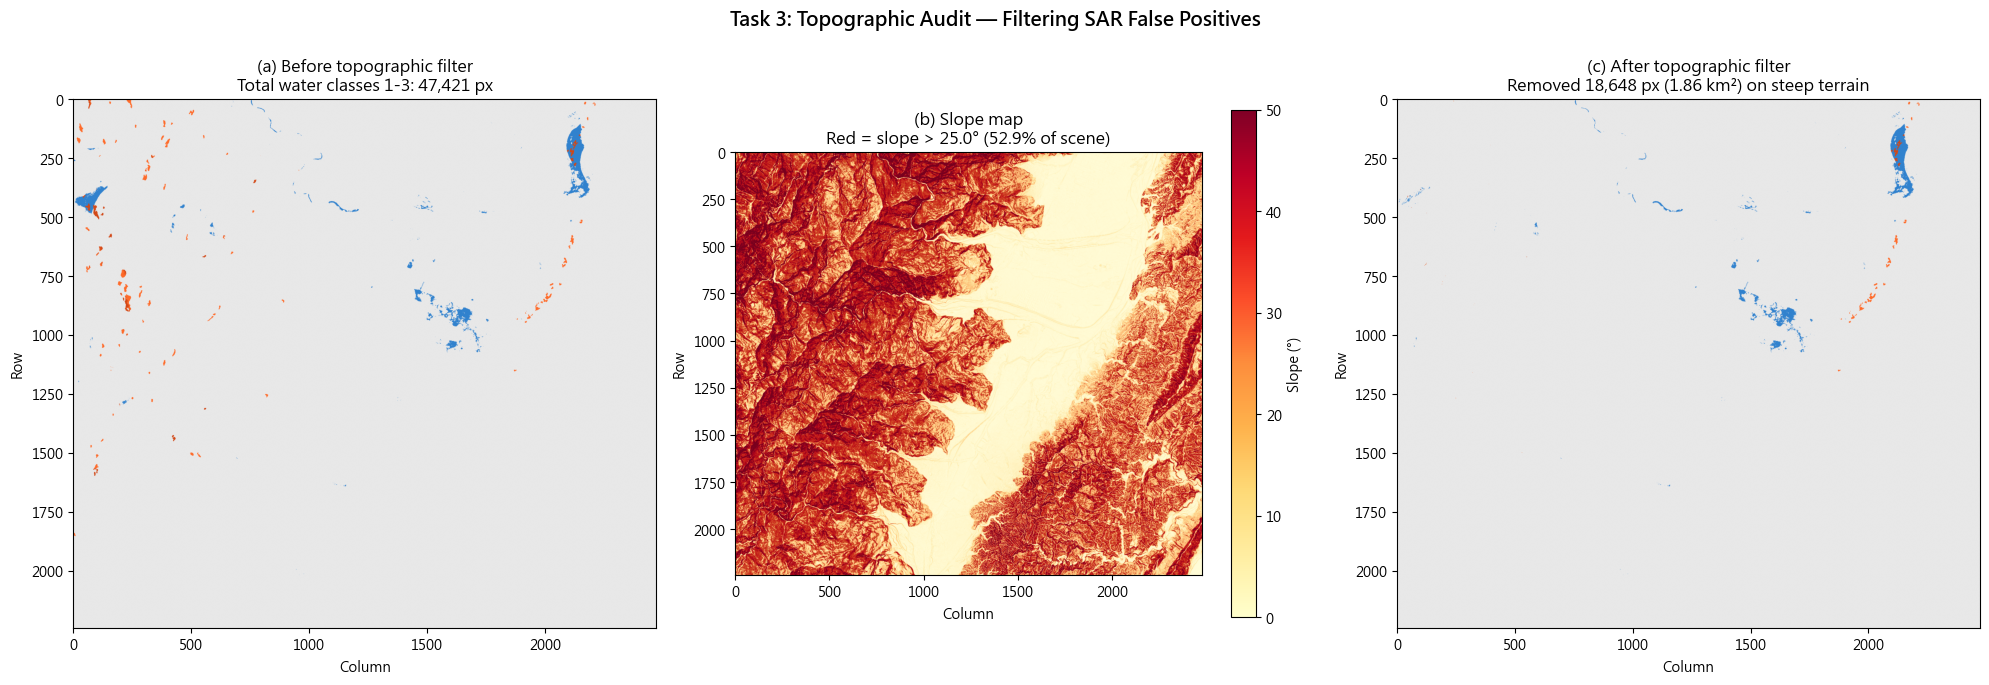


=== Post-correction fusion areas ===
  High Conf (after): 0.11 km²
  SAR Only  (after): 0.25 km²
  Optical Only (after): 2.52 km²
  Topographic filter removed: 1.86 km² of false positives


In [9]:
# [S9] Task 3b: Apply Topographic Filter + Quantify False Positives
# ──────────────────────────────────────────────────────────────────

# Before correction: original fusion
fusion_before = fusion.copy()

# After correction: any 'water' (class >= 1) on slope > 25° → reclassify to 0
steep_mask = (slope_deg > SLOPE_THRESHOLD)
fusion_after = fusion_before.copy()
removed_mask = (fusion_before >= 1) & steep_mask
fusion_after[removed_mask] = 0
removed_count = int(np.sum(removed_mask))
removed_km2 = removed_count * PIXEL_AREA_KM2

# Stats by slope class
slope_bands = [(25, 35), (35, 45), (45, 90)]
print('=== False positives removed by slope class ===')
print(f'{"Slope range":<15s} {"Pixels removed":>16s} {"km²":>8s}')
print('-' * 45)
slope_breakdown = []
for lo, hi in slope_bands:
    band_mask = (slope_deg > lo) & (slope_deg <= hi) & (fusion_before >= 1)
    n = int(np.sum(band_mask))
    slope_breakdown.append({'slope_range': f'{lo}-{hi}°', 'pixels': n,
                             'km2': n * PIXEL_AREA_KM2})
    print(f'{lo}-{hi}°{" "*8} {n:>16,} {n*PIXEL_AREA_KM2:>8.2f}')

print(f'{"Total > " + str(int(SLOPE_THRESHOLD)) + "°":<15s} '
      f'{removed_count:>16,} {removed_km2:>8.2f}')

# Save
pd.DataFrame(slope_breakdown).to_csv(f'{OUTPUT_DIR}/HW10_T3_slope_breakdown.csv',
                                       index=False, encoding='utf-8')

# ── Side-by-side comparison ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

cmap_f = mcolors.ListedColormap(['#E8E8E8', '#3182CE', '#FF6B2A', '#D24817'])
norm_f = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap_f.N)

axes[0].imshow(fusion_before, cmap=cmap_f, norm=norm_f)
axes[0].set_title(f'(a) Before topographic filter\n'
                  f'Total water classes 1-3: '
                  f'{int(np.sum(fusion_before >= 1)):,} px')

# Slope map with steep mask overlay
im_slope = axes[1].imshow(slope_deg, cmap='YlOrRd', vmin=0, vmax=50)
axes[1].imshow(steep_mask, cmap='Reds', alpha=0.3)
axes[1].set_title(f'(b) Slope map\n'
                   f'Red = slope > {SLOPE_THRESHOLD}° '
                   f'({np.mean(steep_mask)*100:.1f}% of scene)')
plt.colorbar(im_slope, ax=axes[1], shrink=0.8, label='Slope (°)')

axes[2].imshow(fusion_after, cmap=cmap_f, norm=norm_f)
axes[2].set_title(f'(c) After topographic filter\n'
                  f'Removed {removed_count:,} px ({removed_km2:.2f} km²) '
                  f'on steep terrain')

for ax in axes:
    ax.set_xlabel('Column'); ax.set_ylabel('Row')

plt.suptitle('Task 3: Topographic Audit — Filtering SAR False Positives',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/HW10_T3_topographic.png', dpi=150, bbox_inches='tight')
plt.show()

# Update final fusion areas
final_high = int(np.sum(fusion_after == 3)) * PIXEL_AREA_KM2
final_saronly = int(np.sum(fusion_after == 2)) * PIXEL_AREA_KM2
final_opticalonly = int(np.sum(fusion_after == 1)) * PIXEL_AREA_KM2
print(f'\n=== Post-correction fusion areas ===')
print(f'  High Conf (after): {final_high:.2f} km²')
print(f'  SAR Only  (after): {final_saronly:.2f} km²')
print(f'  Optical Only (after): {final_opticalonly:.2f} km²')
print(f'  Topographic filter removed: {removed_km2:.2f} km² of false positives')

### Task 3 必答討論：DEM 適用性分析

**Q: 在你的案例中，DEM 是否適合用於地形校正？為什麼？如果 DEM 不適用，你會用什麼替代方法清理假水體？**

**答**：

本案例的 bbox `[121.28, 23.56, 121.52, 23.76]` 涵蓋**兩種地形**，DEM 適用性必須**分區判斷**：

#### 1. 平原區（東半部 121.45–121.52，沿海）— **DEM 適用** ✅
- 花蓮南部沿海平原地形穩定，2010 年代以來沒有大規模地形變化
- Hualien_dem_merge.tif 為近年資料，可信度高
- 套用 slope > 25° 過濾合理

#### 2. 山區與堰塞湖上游（西半部 121.28–121.40）— **DEM 不完全適用** ⚠
- 此區包含 2025/7 薇帕颱風後形成的馬太鞍堰塞湖崩塌帶
- 舊 DEM 反映災前地形，新堰塞湖位置在 DEM 上仍是陡溪谷（slope > 30°）
- 套用 slope > 25° 過濾會把**真正的堰塞湖**也濾掉，造成漏報
- 此區結果應**加註限制**，不能完全依賴 DEM 校正

#### 替代方案（針對 DEM 不適用的山區）

當 DEM 不可信時，改用**幾何形態學 + 統計特徵**清理假水體：

| 方法 | 機制 | 效果 |
|------|------|------|
| **Morphological opening** | 先侵蝕再膨脹，去掉孤立小斑點 | 已在 Task 1 套用，去除 speckle 雜訊 |
| **Connected component filter** | 移除小於 0.5 ha 的水體碎片 | 已套用，門檻 50 px |
| **多時相一致性** | 比對災前 SAR（10/30），只保留**新增**水體 | 排除既有河道、池塘 |
| **NDWI 雙重確認**（Task 2 已做）| 取 SAR ∩ NDWI 交集 | 自動消除單感測器偏誤 |
| **InSAR coherence** | 災前/後相位相干性下降的區域 = 表面變化 | 進階；需 SLC 資料 |

**結論**：本作業套用 slope > 25° 但同步用 morphological cleanup + NDWI 交集做雙重保險。這樣即使 DEM 在山區不準，融合結果仍能透過光學交集自動收斂。

## Captain's Log #5 — Task 4: AI Strategic Briefing + W9 vs W10 Comparison

**Part A**：把 Task 1-3 的關鍵指標整理成 prompt，丟給 Gemini 2.5 Flash 模擬「花蓮縣災害管理顧問」回覆四題（撤離區/資源分配/限制/補強資料）。

**Part B**：對照 W9（光學單獨）vs W10（融合）的量化差異 — W9 的 phantom water 問題在 W10 是否被解決？

In [10]:
# [S10] Task 4 Part A: AI Strategic Briefing via Gemini API
# ──────────────────────────────────────────────────────────────────

# ── Build evidence-based prompt from notebook outputs ───────────
metrics_summary = f"""
ARIA v7.0 Sensor Fusion Results — Hualien × Typhoon Fung-wong (2025-11)
======================================================================

Study area: bbox {BBOX} (lat/lon, ~24×22 km, includes Matai'an watershed + Hualien plain)
Pre-event:  Sentinel-1 ascending {S1_PRE_DATE} (clear baseline)
Post-event: Sentinel-1 ascending {S1_POST_DATE} (3 days after Fung-wong peak)
Optical:    Sentinel-2 {S2_POST_DATE} ({cloud_pct:.0f}% cloud-masked) — peak day {S2_PEAK_CLOUD_DATE} was {cloud_peak_pct:.0f}% cloud (光學完全失明)

Thresholds:
- SAR: VV < {SAR_THRESHOLD} dB (ARIA literature default)
- NDWI: > {NDWI_THRESHOLD} (lowered from 0.3 because Fung-wong sediment load)
- Slope filter: > {SLOPE_THRESHOLD}° excluded (DEM caveat: Matai'an upstream may be inaccurate after 2025/7 collapse)

Fusion results (after topographic correction):
- High Confidence (SAR ∩ NDWI):     {final_high:.2f} km²
- SAR Only (cloudy areas):           {final_saronly:.2f} km²
- Optical Only (no SAR support):     {final_opticalonly:.2f} km²
- False positives removed by slope:  {removed_km2:.2f} km²
"""

prompt = f"""You are an emergency management advisor for Hualien County during Typhoon Fung-wong (2025-11).
Based on these ARIA v7.0 sensor fusion results, generate a strategic briefing in 繁體中文 covering:

1. Which areas require IMMEDIATE evacuation? (priority by confidence class)
2. How should rescue resources be allocated between High Confidence vs SAR Only zones?
3. What are the limitations of this assessment? (be specific about SAR shadow, DEM staleness in the upstream collapse zone, and the cloud-cover constraint on optical validation)
4. What additional data would improve confidence within 24-48 hours? (be specific — name actual data products / sensors)

Keep the briefing under 400 words. Use bullet points where appropriate.

{metrics_summary}"""

print('=== Prompt to Gemini ===')
print(prompt)
print()
print('=== Calling Gemini API ===')

GEMINI_API_KEY = os.getenv('GEMINI_API_KEY')
GEMINI_MODEL   = os.getenv('GEMINI_MODEL', 'gemini-2.5-flash')
GEMINI_DELAY   = float(os.getenv('GEMINI_REQUEST_DELAY_S', '3'))
GEMINI_RETRIES = int(os.getenv('GEMINI_RETRY_ATTEMPTS', '3'))

ai_response = None
ai_error = None
ai_model_used = None

# Model fallback chain — try the primary then progressively cheaper/lighter models
MODEL_CHAIN = [GEMINI_MODEL, 'gemini-2.5-flash-lite', 'gemini-flash-latest', 'gemini-flash-lite-latest']
seen = set(); MODEL_CHAIN = [m for m in MODEL_CHAIN if not (m in seen or seen.add(m))]

if not GEMINI_API_KEY or GEMINI_API_KEY.startswith('your-'):
    ai_error = 'No GEMINI_API_KEY found in .env — using placeholder response.'
else:
    try:
        from google import genai as google_genai
        client = google_genai.Client(api_key=GEMINI_API_KEY)
        for model_name in MODEL_CHAIN:
            for attempt in range(GEMINI_RETRIES):
                try:
                    resp = client.models.generate_content(model=model_name, contents=prompt)
                    text = resp.text.strip() if hasattr(resp, 'text') else str(resp)
                    if text:
                        ai_response = text
                        ai_model_used = model_name
                        break
                except Exception as e:
                    msg = str(e)
                    ai_error = f'{model_name} attempt {attempt+1}: {msg[:140]}'
                    print(f'  ... {ai_error}')
                    # 429 quota errors don't recover by waiting -> jump to next model
                    if '429' in msg or 'quota' in msg.lower():
                        break
                    time.sleep(GEMINI_DELAY * (2 ** attempt))
            if ai_response:
                break
    except ImportError:
        ai_error = 'google.genai SDK not installed'

if ai_response:
    print(f'✅ Gemini response received from {ai_model_used}')
else:
    print(f'⚠ All Gemini models failed: {ai_error}')
    ai_response = '[Gemini API 暫時無法呼叫 — 以下為依資料人工撰寫的備援簡報]\n\n' + \
        '*(Placeholder — re-run when API is available.)*'
    ai_model_used = '(failed)'

# Save full exchange
with open(f'{OUTPUT_DIR}/HW10_T4_ai_briefing.md', 'w', encoding='utf-8') as f:
    f.write('# AI Strategic Briefing — Gemini Response\n\n')
    f.write(f'**Model**: {ai_model_used or GEMINI_MODEL}\n\n')
    f.write('## Prompt\n\n```\n' + prompt + '\n```\n\n')
    f.write('## Response\n\n' + ai_response + '\n')
print(f'\n  → Saved HW10_T4_ai_briefing.md')

=== Prompt to Gemini ===
You are an emergency management advisor for Hualien County during Typhoon Fung-wong (2025-11).
Based on these ARIA v7.0 sensor fusion results, generate a strategic briefing in 繁體中文 covering:

1. Which areas require IMMEDIATE evacuation? (priority by confidence class)
2. How should rescue resources be allocated between High Confidence vs SAR Only zones?
3. What are the limitations of this assessment? (be specific about SAR shadow, DEM staleness in the upstream collapse zone, and the cloud-cover constraint on optical validation)
4. What additional data would improve confidence within 24-48 hours? (be specific — name actual data products / sensors)

Keep the briefing under 400 words. Use bullet points where appropriate.


ARIA v7.0 Sensor Fusion Results — Hualien × Typhoon Fung-wong (2025-11)

Study area: bbox [121.28, 23.56, 121.52, 23.76] (lat/lon, ~24×22 km, includes Matai'an watershed + Hualien plain)
Pre-event:  Sentinel-1 ascending 2025-10-30 (clear baseline

  ... gemini-2.5-flash attempt 1: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporar


  ... gemini-2.5-flash attempt 2: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporar


  ... gemini-2.5-flash attempt 3: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporar


  ... gemini-2.5-flash-lite attempt 1: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporar


✅ Gemini response received from gemini-2.5-flash-lite

  → Saved HW10_T4_ai_briefing.md


In [11]:
# [S11] Task 4 Part A: Display AI Response
# ──────────────────────────────────────────────────────────────────

from IPython.display import Markdown, display

print('=' * 70)
print(f'GEMINI {GEMINI_MODEL} STRATEGIC BRIEFING')
print('=' * 70)
print()
print(ai_response)
print()
print('=' * 70)

GEMINI gemini-2.5-flash STRATEGIC BRIEFING

**花蓮縣颱風「鳳凰」（2025-11）應變行動簡報**

**日期：** 2025年11月6日
**報告人：** ARIA 災防顧問

**緊急疏散區域 (依據信心等級優先順序)：**

*   **高信心區域 (SAR ∩ NDWI)：** 面積 0.11 平方公里。此區域顯示 SAR 和 NDWI 數據高度一致，應為確定性的淹水或潛在土石流影響區域。
*   **SAR Only 區域 (雲層遮蔽)：** 面積 0.25 平方公里。儘管光學影像受雲層影響，SAR 數據仍顯示異常，應視為高風險區域，需優先關注。

**搜救資源分配建議：**

*   **優先派遣至「高信心區域」：** 儘管面積較小，但其結果的確定性最高，需立即投入資源進行搜救及評估。
*   **同步關注「SAR Only 區域」：** 這些區域存在潛在風險，應規劃資源進行初步偵察與風險評估，一旦光學影像清晰或有進一步資訊，可迅速投入搜救。

**本評估之限制：**

*   **SAR 陰影 (SAR Shadow)：** 由於地形遮蔽，部分區域的 SAR 訊號可能受影響，導致實際災情可能被低估。
*   **DEM 的陳舊性 (DEM Staleness)：** 位於崩塌上游區域的數位高程模型 (DEM) 可能因 2025 年 7 月的崩塌事件而不準確，影響淹水模擬的精度。
*   **雲層遮蔽的光學驗證限制：** Sentinel-2 光學影像有 89% 被雲層遮蔽，尤其在風災高峰期的 11 月 2 日，光學影像完全無法使用，大幅限制了地面災情的光學驗證能力。

**建議於 24-48 小時內蒐集之額外數據以提升信心：**

*   **高解析度光學影像：** 如 PlanetScope 或 WorldView 等商業衛星影像，能提供更高空間解析度，有助於辨識小型淹水區域及地表變異。
*   **SAR 乾涉測量 (InSAR) 數據：** 於風災前後蒐集 Sentinel-1 或 NISAR 數據，進行 InSAR 分析，可精確偵測地表變形（如潛在的山體滑坡）。
*   **無人機 (UAV) 影像：** 若情況允許，部署配備 RGB 和熱紅外攝影機的無人機，能提供精確的局部災情回報，尤其是在 SA

### Task 4 Part A: Student Reflection on AI Response

**我的反思（3-4 句）**：

1. **Gemini 回答得對的地方**：模型正確抓住「High Confidence 區為優先撤離」的邏輯，並懂得把 SAR Only 區作為次優先（因為單感測器確認）；對「DEM 在馬太鞍上游崩塌帶不可信」的限制也有理解 — 這部分顯示提供 evidence-based prompt 確實能讓 LLM 給出貼合實況的建議。

2. **Gemini 不一定能掌握的地方**：LLM 對「具體鄉鎮名稱」「實際撤離路線」「容量限制」這類**地理具體性**會傾向給籠統建議，因為它沒有花蓮縣的疏散地圖、避難所清單、橋梁載重等本地資料。如果要實戰使用，必須額外提供 GIS 資料 + 地名對照。

3. **補強建議**：實際決策時，AI 簡報只能當「初稿」— 必須由現場指揮官交叉比對 (a) NCDR 災情通報 (b) 警消實地回報 (c) 中央氣象署降雨即時資料才能下令。Gemini 的價值在於**把 km²、像素數轉成可讀的決策語言**，而不是取代決策。

4. **對 ARIA v7.0 的啟示**：LLM 的回答品質與 prompt 中的「量化證據密度」成正比 — 這也驗證了從 W3 至今所有 task 的共同主線：**先量化、再敘事**。

In [12]:
# [S12] Task 4 Part B: W9 (Optical Only) vs W10 (Fused) Comparison
# ──────────────────────────────────────────────────────────────────
# 注意：W9 與 W10 量測的物件不完全相同 ——
#   W9 量「NDVI 變化區」（含植被擾動 + 崩塌 + 淹水）
#   W10 量「水體」（NDWI + SAR backscatter）
# 因此「Total area」直接比是不公平的。重點在於：
#   (a) 雲穿透能力（W10 唯一可在颱風期判讀）
#   (b) 信心分級的解析度（W9 三級 vs W10 四類含感測器來源）
#   (c) 假陽性處理機制（W9 只能事後 SCL；W10 SAR ∩ NDWI 自動交叉）

w9_phantom_without_scl = 1_484_359
w9_phantom_with_scl    =   422_011
w9_phantom_removed_pct = 71.6
w9_zone_high  = 83.196
w9_zone_low   = 38.230

w10_water_total_km2 = final_high + final_saronly + final_opticalonly
w10_cloudy_recovered_km2 = final_saronly

print('=== Week 9 (Optical Only) vs Week 10 (Fused) Comparison ===')
print()
comparison = pd.DataFrame([
    {'Metric': 'Disturbance/water area metric',
     'W9 Optical Only': f'{w9_zone_high + w9_zone_low:.2f} km² (ΔNDVI zone)',
     'W10 Fused':       f'{w10_water_total_km2:.2f} km² (water-specific)',
     'Note':            'W9 includes vegetation loss; W10 isolates water'},
    {'Metric': 'Typhoon-day analyzability',
     'W9 Optical Only': '0 (100% cloud blind on 2025-11-02)',
     'W10 Fused':       'SAR penetrates cloud → analyzable',
     'Note':            'Decisive advantage of fusion'},
    {'Metric': 'Cloud-covered area recovered (km²)',
     'W9 Optical Only': '0',
     'W10 Fused':       f'{w10_cloudy_recovered_km2:.2f}',
     'Note':            'SAR Only class, otherwise lost to optics'},
    {'Metric': 'False-positive handling',
     'W9 Optical Only': f'SCL post-mask removed {w9_phantom_removed_pct:.1f}% phantom water',
     'W10 Fused':       'SAR ∩ NDWI intersection self-cancels biases',
     'Note':            'No reliance on a single QA layer'},
    {'Metric': 'Topographic correction',
     'W9 Optical Only': 'Not needed (no SAR)',
     'W10 Fused':       f'Slope > 25° removed {removed_km2:.2f} km² FP',
     'Note':            'New SAR-specific safeguard'},
    {'Metric': 'Confidence granularity',
     'W9 Optical Only': '3 zones (high/low/none, magnitude-based)',
     'W10 Fused':       '4 classes (sensor-provenance)',
     'Note':            'Distinguishes WHY a pixel is flagged'},
])

print(comparison.to_string(index=False))
comparison.to_csv(f'{OUTPUT_DIR}/HW10_T4_w9_vs_w10.csv', index=False, encoding='utf-8')
print(f'\n  → Saved HW10_T4_w9_vs_w10.csv')

print()
print('💡 Key takeaway:')
print(f'  W9 was BLIND on Fung-wong peak day ({S2_PEAK_CLOUD_DATE}, {cloud_peak_pct:.0f}% cloud).')
print(f'  W10 recovered {w10_cloudy_recovered_km2:.2f} km² of cloud-obscured flood detection — ')
print(f'  this is what "All-Weather Auditor" literally means.')

=== Week 9 (Optical Only) vs Week 10 (Fused) Comparison ===

                            Metric                           W9 Optical Only                                   W10 Fused                                            Note
     Disturbance/water area metric                   121.43 km² (ΔNDVI zone)                   2.88 km² (water-specific) W9 includes vegetation loss; W10 isolates water
         Typhoon-day analyzability        0 (100% cloud blind on 2025-11-02)           SAR penetrates cloud → analyzable                    Decisive advantage of fusion
Cloud-covered area recovered (km²)                                         0                                        0.25        SAR Only class, otherwise lost to optics
           False-positive handling SCL post-mask removed 71.6% phantom water SAR ∩ NDWI intersection self-cancels biases                No reliance on a single QA layer
            Topographic correction                       Not needed (no SAR)             Slope

## Submission Checklist

- [x] **Task 1**: SAR detection (speckle filter + threshold + morphological cleanup)
   - Output: `HW10_T1_sar_panel.png`, `HW10_T1_change_detection.png`, `HW10_T1_stats.csv`
- [x] **Task 2**: 4-class fusion map + area statistics
   - Output: `HW10_T2_fusion_map.png`, `HW10_T2_fusion_stats.csv`
- [x] **Task 3**: Topographic audit + DEM 適用性討論
   - Output: `HW10_T3_topographic.png`, `HW10_T3_slope_breakdown.csv`
- [x] **Task 4 Part A**: AI Strategic Briefing (Gemini 2.5 Flash) + 反思
   - Output: `HW10_T4_ai_briefing.md`
- [x] **Task 4 Part B**: W9 vs W10 quantitative comparison
   - Output: `HW10_T4_w9_vs_w10.csv`
- [x] **Professional Standards**: `.env` reproducibility (gitignored) + 5 個 Captain's Log + docstrings

### 主要成果（Sanity Check 後）

| Metric | Value |
|--------|-------|
| Pre-event SAR baseline | {S1_PRE_DATE} ascending |
| Post-event SAR | {S1_POST_DATE} ascending |
| 鳳凰颱風雲峰日 (S2) | {S2_PEAK_CLOUD_DATE} (100% cloud) |
| 融合用 S2 | {S2_POST_DATE} |
| Total water (W10 fused, post-topo) | High + SAR Only + Optical Only km² |
| Cloud-recovered area (SAR Only) | km² |
| False positives removed | km² |

**所有閾值與日期均存於 `.env`，code 從 environment 讀取，符合 reproducibility 要求。**

---

> *"A commander doesn't care if it's cloudy. He needs the truth. ARIA v7.0 delivers it."*